# Chapter 6 Companion Notebook  
## Tail Risk under Unknown Loss Distributions

This notebook is the Python companion for **Chapter 6** of *Risk Analytics*.

It is designed to do five things:

1. implement **empirical VaR, TCE, and exact empirical CVaR** from finite samples,
2. show the **linear-programming representation** of empirical mean--CVaR optimization,
3. generate the chapter’s **1000-scenario asymmetric bimodal demand sample**,
4. solve the **newsvendor problem** under empirical tail-risk optimization,
5. reproduce the chapter-style **sensitivity analysis** in the parameters \(\lambda\) and \(\alpha\).

The notebook follows the notation of the chapter:
- $q$: order quantity,
- $D$: demand,
- $L(q,D)$: induced loss,
- $\eta$: VaR-like threshold variable in the LP formulation,
- $u_i$: auxiliary excess-loss variables,
- $\mathrm{VaR}_\alpha$: Value at Risk,
- $\mathrm{TCE}_\alpha$: Tail Conditional Expectation,
- $\mathrm{CVaR}_\alpha$: exact empirical Conditional Value at Risk.


## 0. Imports and plotting style

This cell loads the packages used throughout the notebook and defines the figure directory used by the chapter.


In [1]:
from pathlib import Path
from textwrap import dedent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from scipy.optimize import linprog

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["lines.linewidth"] = 2

FIG_DIR = Path("figures/chapter_6")
FIG_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(42)


## 1. Empirical VaR, TCE, and CVaR from a finite sample

Chapter 6 generalizes the tail-risk measures of Chapters 4 and 5 to the case in which the loss distribution is not known analytically and is instead approximated empirically.

The key points are:

- empirical $\mathrm{VaR}_\alpha$ is a sample quantile,
- empirical $\mathrm{TCE}_\alpha$ averages all losses at or above empirical VaR,
- exact empirical $\mathrm{CVaR}_\alpha$ averages the worst exactly $1-\alpha$ probability mass,
- empirical mean--CVaR optimization can be implemented with a linear program using auxiliary scenario variables.


### 1A. Helper functions for empirical tail risk


In [3]:
def empirical_var(losses, alpha, probs=None):
    losses = np.asarray(losses, dtype=float)
    if probs is None:
        probs = np.ones(len(losses), dtype=float) / len(losses)
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    order = np.argsort(losses)
    L = losses[order]
    p = probs[order]
    cdf = np.cumsum(p)
    idx = np.searchsorted(cdf, alpha, side="left")
    idx = min(idx, len(L) - 1)
    return float(L[idx])

def empirical_tce(losses, alpha, probs=None):
    losses = np.asarray(losses, dtype=float)
    if probs is None:
        probs = np.ones(len(losses), dtype=float) / len(losses)
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    var = empirical_var(losses, alpha, probs)
    mask = losses >= var
    return float(np.sum(losses[mask] * probs[mask]) / np.sum(probs[mask]))

def empirical_cvar(losses, alpha, probs=None):
    losses = np.asarray(losses, dtype=float)
    if probs is None:
        probs = np.ones(len(losses), dtype=float) / len(losses)
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()

    order = np.argsort(losses)
    L = losses[order]
    p = probs[order]
    cdf = np.cumsum(p)

    idx = np.searchsorted(cdf, alpha, side="left")
    idx = min(idx, len(L) - 1)
    var = float(L[idx])
    F_var = float(cdf[idx])

    mask_gt = L > var
    tail_sum = np.sum(L[mask_gt] * p[mask_gt])
    cvar = (tail_sum + var * (F_var - alpha)) / (1 - alpha)
    return float(cvar)

def summarize_empirical_tail(losses, alpha, probs=None):
    return {
        "alpha": alpha,
        "VaR": empirical_var(losses, alpha, probs),
        "TCE": empirical_tce(losses, alpha, probs),
        "CVaR": empirical_cvar(losses, alpha, probs),
    }


### 1B. Toy finite-sample example

This toy example shows how empirical TCE and exact empirical CVaR can differ in a finite sample because the sample itself is discrete.


In [4]:
toy_losses = np.array([0, 0, 10, 10, 10, 50, 50, 50, 50, 50], dtype=float)
toy_alpha = 0.80

toy_summary = summarize_empirical_tail(toy_losses, toy_alpha)
pd.DataFrame([toy_summary], index=[f"alpha={toy_alpha:.2f}"])


,alpha,VaR,TCE,CVaR
alpha=0.80,0.8,50.0,50.0,25.0


In [5]:
display(Markdown(dedent(f'''
The toy example gives:

$$
\mathrm{{VaR}}_{{{toy_alpha:.2f}}} = {toy_summary["VaR"]:.0f},\qquad
\mathrm{{TCE}}_{{{toy_alpha:.2f}}} = {toy_summary["TCE"]:.0f},\qquad
\mathrm{{CVaR}}_{{{toy_alpha:.2f}}} = {toy_summary["CVaR"]:.0f}.
$$

This is the finite-sample analogue of the Chapter 5 logic: empirical TCE can differ from exact empirical CVaR whenever there is probability mass at the VaR point.
''')))



The toy example gives:

$$
\mathrm{VaR}_{0.80} = 50,\qquad
\mathrm{TCE}_{0.80} = 50,\qquad
\mathrm{CVaR}_{0.80} = 25.
$$

This is the finite-sample analogue of the Chapter 5 logic: empirical TCE can differ from exact empirical CVaR whenever there is probability mass at the VaR point.


## 2. Scenario-based LP formulation for the newsvendor problem

The chapter’s practical emphasis is that empirical mean--CVaR optimization can be implemented as a mathematical program with scenario-specific auxiliary variables.

For the newsvendor loss
$
L(q,D)=C_o(q-D)^+ + C_u(D-q)^+,
$
we introduce:

- $s_i \ge q-d_i$ and $s_i \ge 0$ for overage in scenario $i$,
- $t_i \ge d_i-q$ and $t_i \ge 0$ for underage in scenario $i$,
- $u_i \ge L_i(q)-\eta$ and $u_i \ge 0$ for CVaR excess loss in scenario $i$.

This allows the empirical mean--CVaR problem to be solved using `scipy.optimize.linprog`.


### 2A. Parameter values and loss helpers


In [6]:
Co = 230.0
Cu = 360.0
alpha_base = 0.90
lambda_base = 0.60

def loss(q, D, Co=Co, Cu=Cu):
    D = np.asarray(D, dtype=float)
    return Co * np.maximum(q - D, 0.0) + Cu * np.maximum(D - q, 0.0)

display(Markdown(dedent(f'''
### Newsvendor parameters

- **Overage cost** \(C_o\) = `{Co:.0f}`
- **Underage cost** \(C_u\) = `{Cu:.0f}`
- **Baseline** \((\lambda,\alpha)\) = `({lambda_base:.2f}, {alpha_base:.2f})`
''')))



### Newsvendor parameters

- **Overage cost** \(C_o\) = `230`
- **Underage cost** \(C_u\) = `360`
- **Baseline** \((\lambda,lpha)\) = `(0.60, 0.90)`


### 2B. Generate the empirical demand sample

The chapter uses a 1000-scenario empirical demand sample constructed to be asymmetric and bimodal, with a small stress tail.


In [7]:
N = 1000
mix = RNG.choice([0, 1, 2], size=N, p=[0.72, 0.23, 0.05])

demand = np.empty(N)
demand[mix == 0] = RNG.normal(1120, 110, size=(mix == 0).sum())   # regular season
demand[mix == 1] = RNG.normal(1560, 140, size=(mix == 1).sum())   # surge season
demand[mix == 2] = RNG.normal(1980, 120, size=(mix == 2).sum())   # stress tail
demand = np.clip(demand, 500, None)
demand = np.round(demand, 0)

weights = np.ones(N) / N

pd.Series(demand).describe()


count    1000.000000
mean     1256.990000
std       264.482284
min       795.000000
25%      1080.000000
50%      1172.000000
75%      1402.250000
max      2220.000000
dtype: float64

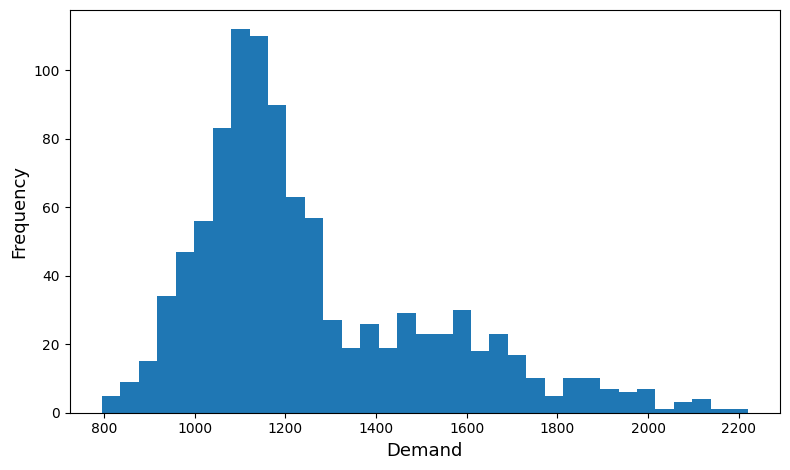

In [8]:
fig = plt.figure()
plt.hist(demand, bins=35)
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_6_1_empirical_demand_histogram.png", dpi=220, bbox_inches="tight")
plt.show()


### 2C. LP solver for empirical mean--CVaR newsvendor optimization


In [12]:
def solve_newsvendor_mean_cvar_lp(demand, Co, Cu, lam, alpha, probs=None, q_bounds=(0, None)):
    demand = np.asarray(demand, dtype=float)
    N = len(demand)
    if probs is None:
        probs = np.ones(N, dtype=float) / N
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()

    # variable order: q | eta | s_1..s_N | t_1..t_N | u_1..u_N
    nvar = 2 + 3 * N
    q_idx = 0
    eta_idx = 1
    s0 = 2
    t0 = 2 + N
    u0 = 2 + 2 * N

    c = np.zeros(nvar)
    c[eta_idx] = lam
    c[s0:s0+N] = probs * Co
    c[t0:t0+N] = probs * Cu
    c[u0:u0+N] = lam * probs / (1 - alpha)

    A_ub = []
    b_ub = []

    # s_i >= q - d_i  => q - s_i <= d_i
    for i, d in enumerate(demand):
        row = np.zeros(nvar)
        row[q_idx] = 1.0
        row[s0 + i] = -1.0
        A_ub.append(row)
        b_ub.append(d)

    # t_i >= d_i - q  => -q - t_i <= -d_i
    for i, d in enumerate(demand):
        row = np.zeros(nvar)
        row[q_idx] = -1.0
        row[t0 + i] = -1.0
        A_ub.append(row)
        b_ub.append(-d)

    # u_i >= Co s_i + Cu t_i - eta  => Co s_i + Cu t_i - eta - u_i <= 0
    for i in range(N):
        row = np.zeros(nvar)
        row[eta_idx] = -1.0
        row[s0 + i] = Co
        row[t0 + i] = Cu
        row[u0 + i] = -1.0
        A_ub.append(row)
        b_ub.append(0.0)

    bounds = [q_bounds, (None, None)] + [(0, None)] * (3 * N)

    res = linprog(
        c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        bounds=bounds,
        method="highs"
    )
    if not res.success:
        raise RuntimeError(res.message)

    x = res.x
    q = x[q_idx]
    eta = x[eta_idx]
    s = x[s0:s0+N]
    t = x[t0:t0+N]
    u = x[u0:u0+N]

    losses = Co * s + Cu * t
    mean_loss = float(np.sum(probs * losses))
    cvar = float(eta + np.sum(probs * u) / (1 - alpha))
    obj = mean_loss + lam * cvar

    return {
        "q_star": float(q),
        "eta_star": float(eta),
        "mean_loss": mean_loss,
        "cvar": cvar,
        "objective": obj,
        "losses": losses,
        "u": u,
        "result": res,
    }

baseline_lp = solve_newsvendor_mean_cvar_lp(
    demand=demand,
    Co=Co,
    Cu=Cu,
    lam=lambda_base,
    alpha=alpha_base,
    probs=weights,
    q_bounds=(700, 2400)
)

pd.DataFrame([{
    "q*": round(baseline_lp["q_star"], 2),
    "eta*": round(baseline_lp["eta_star"], 2),
    "E[L]": round(baseline_lp["mean_loss"], 2),
    "CVaR": round(baseline_lp["cvar"], 2),
    "Objective": round(baseline_lp["objective"], 2),
}])


,q*,eta*,E[L],CVaR,Objective
0,1417.8,113113.22,71204.11,157339.52,165607.82


### 2D. Summary table for selected order quantities

To match the chapter presentation, we also evaluate three order quantities near the LP optimum.


In [15]:
# Table 6.1: exact benchmark solutions

# 1) Risk-neutral solution: minimize E[L]
risk_neutral_lp = solve_newsvendor_mean_cvar_lp(
    demand=demand,
    Co=Co,
    Cu=Cu,
    lam=0.0,
    alpha=alpha_base,
    probs=weights,
    q_bounds=(700, 2400)
)

# 2) Baseline mean-CVaR solution: minimize E[L] + lambda * CVaR
# baseline_lp already exists, but this keeps the cell self-contained
baseline_lp = solve_newsvendor_mean_cvar_lp(
    demand=demand,
    Co=Co,
    Cu=Cu,
    lam=lambda_base,
    alpha=alpha_base,
    probs=weights,
    q_bounds=(700, 2400)
)

# 3) Pure CVaR solution: approximate by using a very large lambda
# (same solver, no need for a separate function)
cvar_lp = solve_newsvendor_mean_cvar_lp(
    demand=demand,
    Co=Co,
    Cu=Cu,
    lam=1e6,
    alpha=alpha_base,
    probs=weights,
    q_bounds=(700, 2400)
)

benchmark_qs = [
    float(risk_neutral_lp["q_star"]),
    float(baseline_lp["q_star"]),
    float(cvar_lp["q_star"]),
]

rows = []
for q in benchmark_qs:
    losses = loss(q, demand)
    mean = float(np.sum(weights * losses))
    var = empirical_var(losses, alpha_base)
    cvar = empirical_cvar(losses, alpha_base)

    rows.append({
        "q": round(q, 2),
        "E[L(q,D)]": round(mean, 2),
        "VaR_0.90": round(var, 2),
        "CVaR_0.90": round(cvar, 2),
        "E[L]+0.6 CVaR": round(mean + lambda_base * cvar, 2),
    })

table_ch6_1 = pd.DataFrame(rows)
table_ch6_1

,q,"E[L(q,D)]",VaR_0.90,CVaR_0.90,E[L]+0.6 CVaR
0,1230.00,61232.84,152280.00,214315.20,189821.96
1,1417.80,71204.11,113113.22,155077.26,164250.46
2,1506.37,80225.88,126585.76,150252.86,170377.60


### 2E. Empirical loss distribution at the representative order quantity


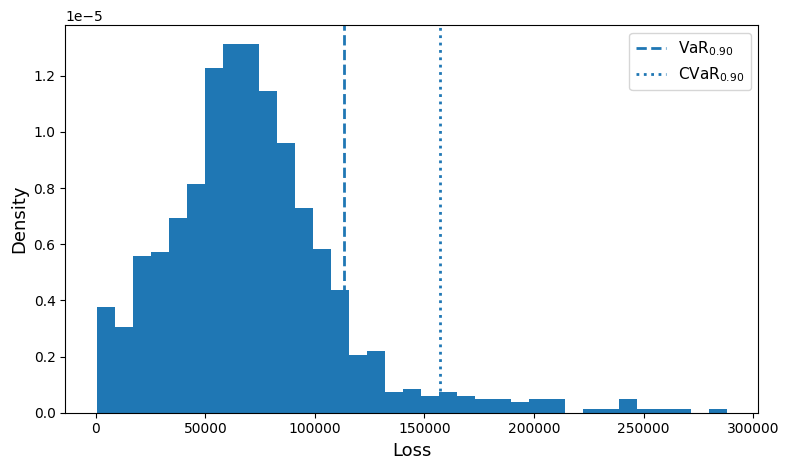

In [16]:
rep_losses = loss(q_rep, demand)
rep_var = empirical_var(rep_losses, alpha_base)
rep_cvar = empirical_cvar(rep_losses, alpha_base)

fig = plt.figure()
plt.hist(rep_losses, bins=35, density=True)
plt.axvline(rep_var, linestyle="--", label=r"$\mathrm{VaR}_{0.90}$")
plt.axvline(rep_cvar, linestyle=":", label=r"$\mathrm{CVaR}_{0.90}$")
plt.xlabel("Loss")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_6_2_loss_distribution.png", dpi=220, bbox_inches="tight")
plt.show()


### 2F. Mean--CVaR objective as a function of q

For the chapter-style plot, we evaluate the objective on a dense grid of order quantities. The LP formulation is used for optimization; the grid is useful for visualization.


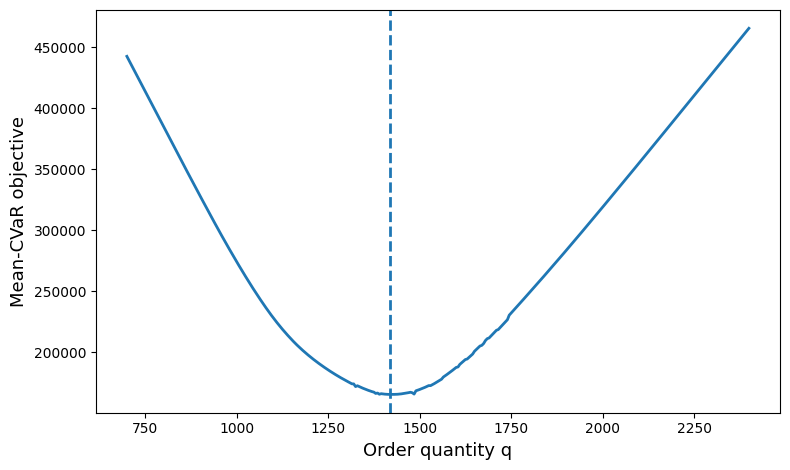


- **Grid-based representative optimum** = `1420`
- **LP optimum** = `1417.80`

The small difference reflects the fact that the grid plot uses 5-unit increments, while the LP solves the continuous piecewise-linear problem.


In [17]:
Q_grid = np.arange(700, 2401, 5)

def mean_cvar_objective_from_sample(q, demand, alpha, lam):
    losses = loss(q, demand)
    return float(losses.mean() + lam * empirical_cvar(losses, alpha))

obj_vals = np.array([mean_cvar_objective_from_sample(q, demand, alpha_base, lambda_base) for q in Q_grid])
q_grid_star = int(Q_grid[np.argmin(obj_vals)])

fig = plt.figure()
plt.plot(Q_grid, obj_vals)
plt.axvline(q_grid_star, linestyle="--")
plt.xlabel("Order quantity q")
plt.ylabel("Mean-CVaR objective")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_6_3_objective_baseline.png", dpi=220, bbox_inches="tight")
plt.show()

display(Markdown(dedent(f'''
- **Grid-based representative optimum** = `{q_grid_star}`
- **LP optimum** = `{baseline_lp["q_star"]:.2f}`

The small difference reflects the fact that the grid plot uses 5-unit increments, while the LP solves the continuous piecewise-linear problem.
''')))


### 2G. Optimal order quantity as a function of lambda

Here the LP formulation is used directly for each value of \(\lambda\).


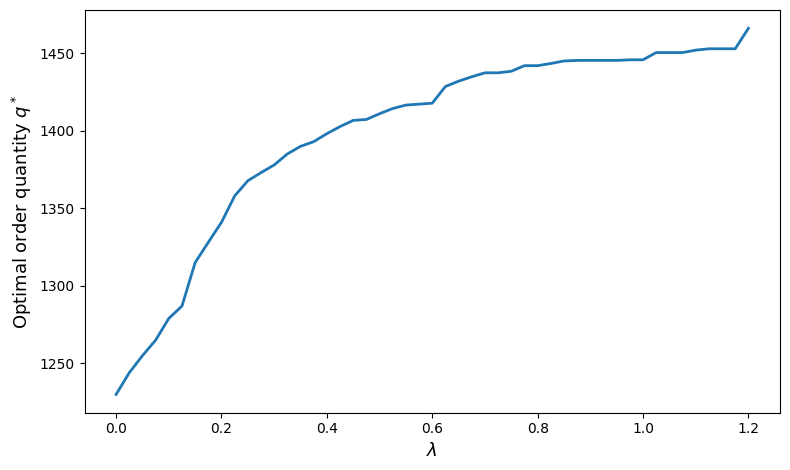

In [18]:
lambda_grid = np.linspace(0, 1.2, 49)

q_lambda = []
for lam in lambda_grid:
    sol = solve_newsvendor_mean_cvar_lp(
        demand=demand,
        Co=Co,
        Cu=Cu,
        lam=float(lam),
        alpha=alpha_base,
        probs=weights,
        q_bounds=(700, 2400)
    )
    q_lambda.append(sol["q_star"])

fig = plt.figure()
plt.plot(lambda_grid, q_lambda)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"Optimal order quantity $q^*$")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_6_5_optimal_q_vs_lambda.png", dpi=220, bbox_inches="tight")
plt.show()


### 2H. Objective curves for different values of lambda


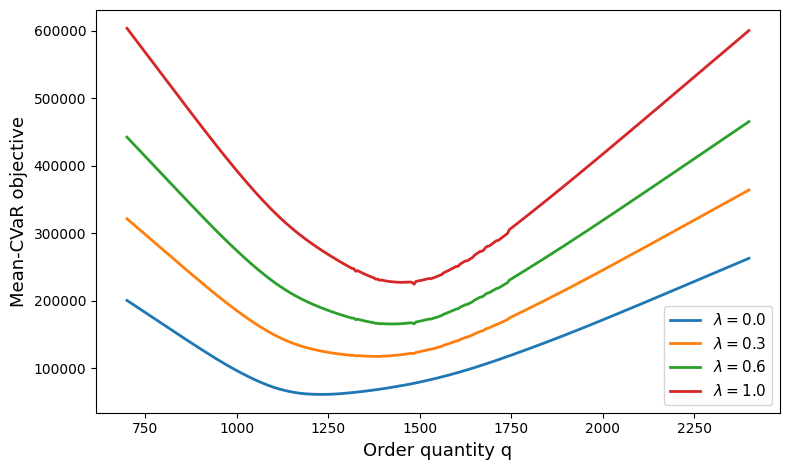

In [20]:
fig = plt.figure()
for lam in [0.0, 0.3, 0.6, 1.0]:
    vals = np.array([mean_cvar_objective_from_sample(q, demand, alpha_base, lam) for q in Q_grid])
    plt.plot(Q_grid, vals, label=fr"$\lambda={lam}$")
plt.xlabel("Order quantity q")
plt.ylabel("Mean-CVaR objective")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_6_4_objective_lambda_variants.png", dpi=220, bbox_inches="tight")
plt.show()


### 2I. Objective curves for different values of alpha


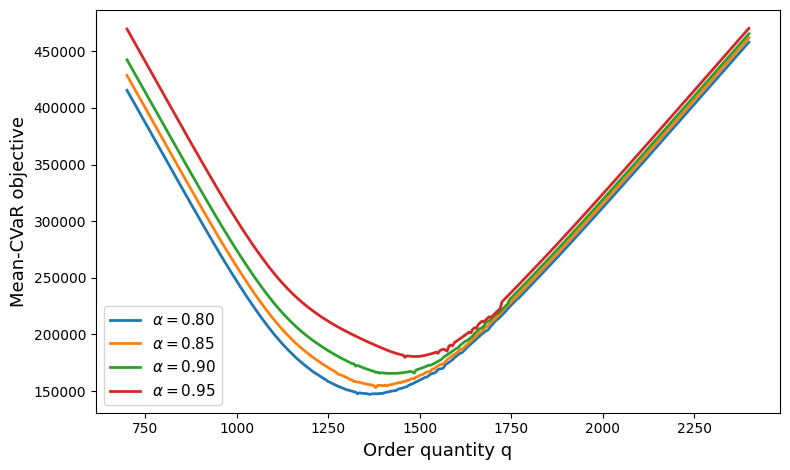

In [24]:
fig = plt.figure()
for alpha in [0.80, 0.85, 0.90, 0.95]:
    vals = np.array([mean_cvar_objective_from_sample(q, demand, alpha, lambda_base) for q in Q_grid])
    plt.plot(Q_grid, vals, label=fr"$\alpha={alpha:.2f}$")
plt.xlabel("Order quantity q")
plt.ylabel("Mean-CVaR objective")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_6_6_objective_alpha_variants.png", dpi=220, bbox_inches="tight")
plt.show()


### 2J. Optimal order quantity as a function of alpha

Again, the LP formulation is used directly for each value of \(\alpha\).


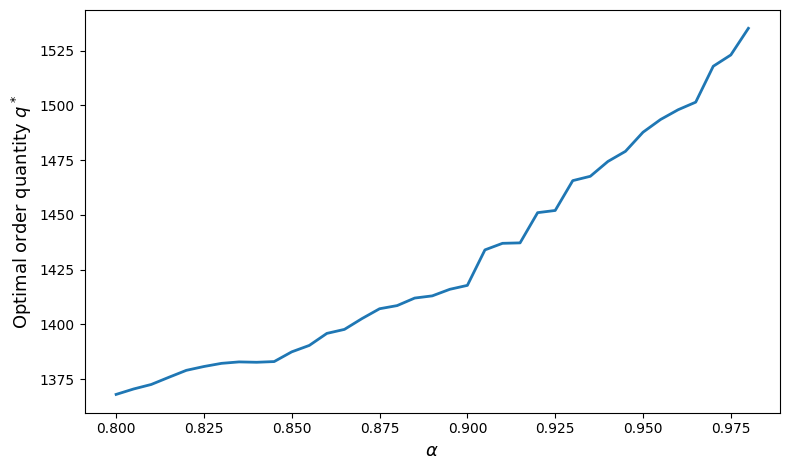

In [25]:
alpha_grid = np.linspace(0.80, 0.98, 37)

q_alpha = []
for alpha in alpha_grid:
    sol = solve_newsvendor_mean_cvar_lp(
        demand=demand,
        Co=Co,
        Cu=Cu,
        lam=lambda_base,
        alpha=float(alpha),
        probs=weights,
        q_bounds=(700, 2400)
    )
    q_alpha.append(sol["q_star"])

fig = plt.figure()
plt.plot(alpha_grid, q_alpha)
plt.xlabel(r"$\alpha$")
plt.ylabel(r"Optimal order quantity $q^*$")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_6_7_optimal_q_vs_alpha.png", dpi=220, bbox_inches="tight")
plt.show()


## 3. Sensitivity to sample size

This section reproduces the chapter’s point that empirical tail-risk recommendations can be sensitive to the effective sample size.


In [26]:
rows = []
for n in [50, 100, 250, 1000]:
    Dn = demand[:n]
    wn = np.ones(n) / n
    sol = solve_newsvendor_mean_cvar_lp(
        demand=Dn,
        Co=Co,
        Cu=Cu,
        lam=lambda_base,
        alpha=alpha_base,
        probs=wn,
        q_bounds=(700, 2400)
    )
    rows.append({
        "Sample size N": n,
        "Optimal q*": round(sol["q_star"], 2),
        "E[L(q*,D)]": round(sol["mean_loss"], 2),
        "CVaR_0.90": round(sol["cvar"], 2),
    })

sample_size_table = pd.DataFrame(rows)
sample_size_table


,Sample size N,Optimal q*,"E[L(q*,D)]",CVaR_0.90
0,50,1432.61,66382.94,155348.34
1,100,1397.42,64999.96,150177.46
2,250,1412.68,67609.25,151440.33
3,1000,1417.80,71204.11,157339.52


## 4. Sensitivity to scenario representation

This section compares the baseline empirical sample with recency-weighted, stress-augmented, and fitted-normal scenario constructions.


In [28]:
# recency-weighted historical
rec_w = np.array([0.995 ** (N - 1 - i) for i in range(N)], dtype=float)
rec_w /= rec_w.sum()

# stress-augmented sample
stress_extra = RNG.normal(2200, 80, size=40)
stress_extra = np.clip(stress_extra, 500, None)
stress_extra = np.round(stress_extra, 0)

stress_D = np.concatenate([demand, stress_extra])
stress_w = np.concatenate([
    np.repeat(0.96 / len(demand), len(demand)),
    np.repeat(0.04 / len(stress_extra), len(stress_extra))
])

# fitted normal simulation
mu_hat = demand.mean()
sigma_hat = demand.std(ddof=1)
sim_D = RNG.normal(mu_hat, sigma_hat, size=1000)

sim_D = np.clip(sim_D, 500, None)
sim_w = np.ones(len(sim_D)) / len(sim_D)

rows = []
for method, D, w in [
    ("Historical sample", demand, weights),
    ("Recency-weighted historical", demand, rec_w),
    ("Stress-augmented sample", stress_D, stress_w),
    ("Fitted normal simulation", sim_D, sim_w),
]:
    sol = solve_newsvendor_mean_cvar_lp(
        demand=D,
        Co=Co,
        Cu=Cu,
        lam=lambda_base,
        alpha=alpha_base,
        probs=w,
        q_bounds=(700, 2400)
    )
    rows.append({
        "Method": method,
        "Optimal q*": round(sol["q_star"], 2),
        "E[L]": round(sol["mean_loss"], 2),
        "CVaR_0.90": round(sol["cvar"], 2),
        "E[L]+0.6 CVaR": round(sol["objective"], 2),
    })

scenario_table = pd.DataFrame(rows)
scenario_table


,Method,Optimal q*,E[L],CVaR_0.90,E[L]+0.6 CVaR
0,Historical sample,1417.80,71204.11,157339.52,165607.82
1,Recency-weighted historical,1439.15,75820.50,162138.25,173103.46
2,Stress-augmented sample,1519.31,88373.63,195118.03,205444.45
3,Fitted normal simulation,1363.99,58931.61,150360.29,149147.79


## 5. Key takeaway table

This table collects the main numerical outputs used in the chapter.


In [30]:
key_table = pd.DataFrame({
    "Quantity": [
        "Baseline LP-optimal q*",
        "Representative VaR_0.90",
        "Representative CVaR_0.90",
    ],
    "Value": [
        round(baseline_lp["q_star"], 2),
        round(rep_var, 2),
        round(rep_cvar, 2),
    ]
})
key_table


,Quantity,Value
0,Baseline LP-optimal q*,1417.8
1,Representative VaR_0.90,113390.0
2,Representative CVaR_0.90,157014.3


## 6. Notes

- The notebook implements both **empirical tail-measure calculation** and the **finite-scenario LP formulation** of mean--CVaR optimization.
- The figures are saved into `figures/chapter_6/` using the filenames referenced in the chapter text.
- The objective curves are evaluated on a grid for visualization, while the optimal policies in the main sensitivity exercises are obtained directly from the LP formulation.
- Because the scenario set is empirical and finite, the resulting objective curves are naturally piecewise and the function \(q^*(\alpha)\) need not vary monotonically.
